# REG Creative Arts

## Research context

Creative Arts (CategoryKey = 10) is a **control group** discipline in the full cross-category DiD.
Under JRG it faced one of the most significant **fee increases** of any field:

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019   | $6,566                     | $13,073                          |
| 2021+  | $9,522 (+45 %)             | $10,334 (−21 %)                  |

All three countries — AUS, UK, and NZ — saw Creative Arts enrolments decline or stagnate after 2021,
making this a harder identification environment than fields where controls continued growing. The DiD
asks whether AUS declined *more* than the pooled UK + NZ trend, above and beyond any global
contraction in arts enrolments.

### Identifying strategy (country-level DiD)

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK, NZ}\}$, $\text{Post}_t = \mathbf{1}[t \geq 2021]$, and $\beta$ is the JRG effect for Creative Arts. Country fixed effects $\alpha_c$ absorb permanent level differences across all three countries; year fixed effects $\gamma_t$ absorb common time shocks.

**Data window:** AUS 2016–2024 (9 years); UK 2016–2024 (9 years, start-year mapping: 2016/17 → 2016); NZ 2016–2024 (9 years, calendar years).
**Panel:** N = 27 (3 countries × 9 years), df = 15 in the primary specification.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
NZ_PATH   = ROOT / 'data' / 'clean' / 'NZ_bachelors_enrollments_2016_2025.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert NZ_PATH.exists(),   f'Missing: {NZ_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
print('Project root:', ROOT)
print('All data files found.')

## 1. AUS Descriptive Analysis

Examine Australia-only Creative Arts data (2016–2024) to characterise the enrolment trend and
test a simple pre/post break. AUS-only OLS uses a log-linear specification with HC3 robust SEs.

AUS Creative Arts -- enrolment data:


,year,enrollments,log_enrollments
0,2016,93916,11.450156
1,2017,94955,11.461158
2,2018,96195,11.474133
3,2019,97478,11.487382
4,2020,97745,11.490117
5,2021,98528,11.498096
6,2022,93412,11.444775
7,2023,92496,11.434921
8,2024,96142,11.473582


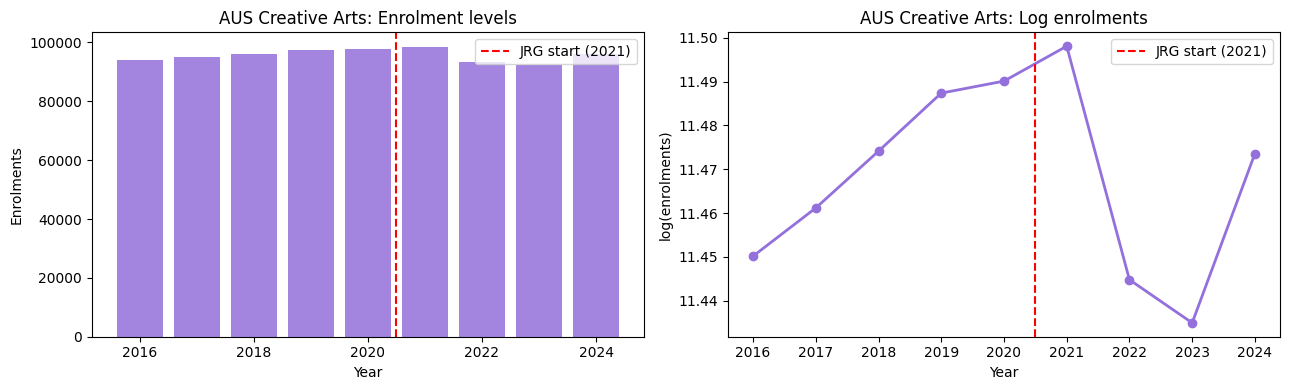

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 10].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Creative Arts -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='mediumpurple', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Creative Arts: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='mediumpurple', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Creative Arts: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()

In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    print(f'R^2 = {result.rsquared:.4f} | Adj. R^2 = {result.rsquared_adj:.4f} | N = {int(result.nobs)}')

m_linear = smf.ols('log_enrollments ~ post_jrg + year_c',           data=arch_aus).fit(cov_type='HC3')
m_quad   = smf.ols('log_enrollments ~ post_jrg + year_c + year_c2', data=arch_aus).fit(cov_type='HC3')

print('=== AUS-only OLS: linear time trend ===')
summary_table(m_linear, ['Intercept', 'post_jrg', 'year_c'])
b_aus = m_linear.params['post_jrg']
print(f'\npost_jrg: ~{b_aus*100:.2f}% change in AUS enrolments post-JRG (controlling for linear trend)')

print('\n=== AUS-only OLS: quadratic time trend ===')
summary_table(m_quad, ['Intercept', 'post_jrg', 'year_c', 'year_c2'])

=== AUS-only OLS: linear time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,11.4769,0.0101,0.0000,11.4571,11.4967
post_jrg,-0.0291,0.0529,0.5827,-0.1328,0.0746
year_c,0.0043,0.0083,0.6063,-0.0120,0.0206


R^2 = 0.1272 | Adj. R^2 = -0.1638 | N = 9

post_jrg: ~-2.91% change in AUS enrolments post-JRG (controlling for linear trend)

=== AUS-only OLS: quadratic time trend ===


,beta,SE (HC3),p,CI lo,CI hi
Variable,,,,,
Intercept,11.4837,0.0043,0.0000,11.4753,11.4922
post_jrg,-0.0188,0.0749,0.8016,-0.1656,0.1280
year_c,0.0060,0.0078,0.4431,-0.0093,0.0214
year_c2,-0.0017,0.0036,0.6374,-0.0088,0.0054


R^2 = 0.3470 | Adj. R^2 = -0.0448 | N = 9


## 2. DiD Panel Construction

Combine AUS, UK, and New Zealand Creative Arts data into a 3-country × year panel for the overlapping window (2016–2024).

**UK year mapping:** start-year rule — `2019/20 → 2019`, `2020/21 → 2020`, etc.
**NZ:** already in long format with calendar years and `category_key`; filter for key = 10. Coverage is all tertiary providers; growth rates are comparable to AUS/UK, but absolute levels are not directly comparable.

**Treatment indicators:**
- `treated = 1` for AUS, `0` for UK and NZ (both are controls)
- `nz_dummy = 1` for NZ, `0` otherwise (UK is the level reference)
- `post = 1` for 2021+
- `did = treated × post` (main DiD interaction)
- `treated_covid2020`, `treated_covid2021` — AUS-specific COVID shock controls

In [ ]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 10].copy()
arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk = arch_uk[['year', 'Total UK']].rename(columns={'Total UK': 'enrollments'})
arch_uk['enrollments'] = pd.to_numeric(arch_uk['enrollments'], errors='coerce')
arch_uk['country'] = 'UK'

nz_raw  = pd.read_csv(NZ_PATH)
arch_nz = nz_raw[nz_raw['category_key'] == 10][['year', 'total_bachelors']].copy()
arch_nz = arch_nz.rename(columns={'total_bachelors': 'enrollments'})
arch_nz['country'] = 'NZ'

arch_aus_did = arch_aus[arch_aus['year'] >= 2016][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

# Restrict all to 2016–2024 (AUS upper bound)
panel = (pd.concat([arch_aus_did, arch_uk, arch_nz], ignore_index=True)
           .query('year <= 2024')
           .sort_values(['country', 'year'])
           .reset_index(drop=True))

panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['nz_dummy']          = (panel['country'] == 'NZ').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020

print('DiD panel -- Creative Arts (AUS vs UK + NZ):')
display(panel[['country','year','enrollments','log_enrollments','treated','nz_dummy','post','did']].reset_index(drop=True))
print(f'\nShape: {panel.shape} | Countries: {sorted(panel["country"].unique())}')
print(f'Pre-treatment years:  {sorted(panel[panel["post"]==0]["year"].unique())}')
print(f'Post-treatment years: {sorted(panel[panel["post"]==1]["year"].unique())}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'mediumpurple', 'UK': 'darkorange', 'NZ': 'seagreen'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],     'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
    ax.legend(); ax.set_xlabel('Year')

axes[0].set_title('Creative Arts: Enrolment levels (AUS vs UK + NZ)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Creative Arts: Log enrolments (AUS vs UK + NZ)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()

print('Pre/post log-enrolment averages:')
for country, grp in panel.groupby('country'):
    pre  = grp[grp['post'] == 0]['log_enrollments'].mean()
    post = grp[grp['post'] == 1]['log_enrollments'].mean()
    print(f'  {country}: pre = {pre:.4f}, post = {post:.4f}, change = {post - pre:+.4f}')

## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(\text{Enrolments}_{ct}) = \alpha_c + \gamma_t + \beta(\text{AUS}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c \in \{\text{AUS, UK, NZ}\}$. Implemented as OLS with `treated` (AUS country FE), `nz_dummy` (NZ vs UK level), `C(year)` (year FEs), and `did` (DiD interaction). UK is the reference country. All SEs are HC3 robust.

**Degrees-of-freedom:** N = 27 (3 countries × 9 years). Parameters: intercept + treated + nz_dummy + 8 year dummies + did = 12, leaving **df = 15**. The COVID-controlled spec (`treated_covid2020`, `treated_covid2021`) is also feasible at df = 13 and is shown alongside the primary spec.

> **Context:** All three countries saw Creative Arts enrolments decline or stagnate post-2021. The year FEs absorb the common global contraction in arts enrolments; `did` isolates any AUS-specific excess decline above that common trend.

In [ ]:
formula_main = 'log_enrollments ~ treated + nz_dummy + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'N = {int(model_main.nobs)} | df_resid = {int(model_main.df_resid)}')
direction = 'lower' if did_b < 0 else 'higher'
print(f'\nInterpretation: Post-JRG (2021+), AUS Creative Arts enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the pooled UK + NZ trend would predict.')

# COVID-controlled spec — now feasible with N=27 (df=13)
formula_covid = 'log_enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv  = m_covid.params.get('did', np.nan)
se_cv = m_covid.bse.get('did', np.nan)
p_cv  = m_covid.pvalues.get('did', np.nan)
print(f'\nCOVID-controlled spec (df={int(m_covid.df_resid)}): beta_did = {b_cv:.4f}, SE = {se_cv:.4f}, p = {p_cv:.4f}')

In [ ]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-4
print('Estimates match ✓' if match else f'Note: small numerical discrepancy — OLS={did_b:.6f}, PanelOLS={fe_model.params["did"]:.6f}')

## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions. With N = 27 (3 countries × 9 years) and df = 15, all variants have adequate degrees of freedom for reliable inference.

| Spec | N | df | Inference quality |
|------|---|----|-------------------|
| Full panel (2016–2024) | 27 | 15 | Good |
| Drop 2020 | 24 | 13 | Good |
| Drop 2020 + 2021 | 21 | 11 | Good |

In [ ]:
formula_simple = 'log_enrollments ~ treated + nz_dummy + did + C(year)'

variants = {
    'Full panel (2016-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (TWFE, HC3) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nSign consistency and magnitude stability across all sample restrictions are the key diagnostics.')

## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically:

$$\hat{\delta}_t = \left(\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}\right) - \left(\frac{\log Y_{\text{UK},t} + \log Y_{\text{NZ},t}}{2} - \frac{\log Y_{\text{UK},2020} + \log Y_{\text{NZ},2020}}{2}\right)$$

The pooled control is the simple average of UK and NZ log-enrolments. This is numerically close to the TWFE coefficient when the two control countries have similar level variation.

> **Limitation:** Per-year standard errors are not estimable analytically with 3 units. The 2016–2019 pre-treatment point estimates serve as the parallel trends diagnostic.

In [ ]:
base_year = 2020
aus_log  = panel.query("country == 'AUS'").set_index('year')['log_enrollments']
uk_log   = panel.query("country == 'UK'").set_index('year')['log_enrollments']
nz_log   = panel.query("country == 'NZ'").set_index('year')['log_enrollments']

# Pooled control: equal-weighted average of UK and NZ
ctrl_log = (uk_log + nz_log) / 2

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log.get(yr, np.nan) - aus_log[base_year]) - \
           (ctrl_log.get(yr, np.nan) - ctrl_log[base_year])
    event_rows.append({'year': yr, 'coef': round(float(coef), 6) if pd.notna(coef) else np.nan})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.25, 0.25, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='mediumpurple', linewidth=2,
        label='DiD point estimate (AUS vs pooled UK+NZ, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='mediumpurple', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Creative Arts (AUS vs pooled UK+NZ)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (AUS vs pooled UK+NZ):')
ev['approx_%'] = ev['coef'].apply(lambda c: round((np.exp(c) - 1) * 100, 2) if pd.notna(c) else np.nan)
ev['period'] = ev['year'].apply(lambda y: 'Pre' if y < 2021 else ('Baseline' if y == base_year else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: With 3 countries, per-year SEs require bootstrapping — not shown here.')
print('Pre-treatment estimates near zero support the parallel trends assumption.')

## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016-2020) and test
for a fake structural break at 2019. A significant break would suggest pre-existing non-linear trends
that could contaminate the main DiD.

> **Limitation:** N = 5 observations (single series, no control group). Power is minimal; indicative only.

In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break -- consistent with JRG driving the post-2021 pattern.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')

=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     10.17
Date:                Sat, 25 Apr 2026   Prob (F-statistic):             0.0895
Time:                        18:29:36   Log-Likelihood:                 22.587
No. Observations:                   5   AIC:                            -39.17
Df Residuals:                       2   BIC:                            -40.35
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness check.
The level DiD coefficient gives the absolute headcount difference attributable to JRG relative to UK trend.

In [ ]:
formula_level = 'enrollments ~ treated + nz_dummy + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did']

print('=== Level Outcome Robustness ===')
print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4),  round(b_lev, 0)],
    'p-value':        [round(did_p, 4),  round(p_lev, 4)],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year',
    ],
}).set_index('Specification')
display(comp)

## 8. Funding Context

Creative Arts had the sharpest student fee increase of any field under JRG (~+45%), alongside a
significant drop in Commonwealth support (~-21%). This funding context is crucial: if AUS enrolments
fell more than the UK, the fee increase is the most plausible mechanism.

Note that both countries saw declines -- the question is whether AUS's decline was disproportionate.

=== Creative Arts: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,6566.0,13073.0,19639.0
2020,6684.0,13308.0,19992.0
2021,9522.0,10334.0,19856.0
2022,9607.0,10427.0,20034.0
2023,9943.0,10791.0,20734.0
2024,10718.0,11632.0,22350.0


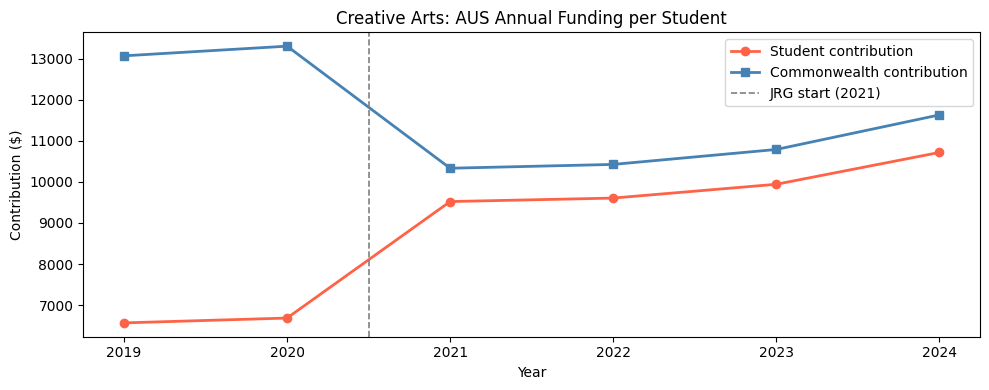


Student contribution: pre $6,625 -> post $9,948 (+50.2%)
Commonwealth:         pre $13,190 -> post $10,796 (-18.2%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 10].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Creative Arts: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato',    linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='steelblue', linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title('Creative Arts: AUS Annual Funding per Student')
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')

## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{NZ}_c + \beta_3 \cdot \text{DID}_{ct} + \sum_{t=2017}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2016, reference country) |
| $\beta_1 \cdot \text{Treated}_c$ | AUS country FE | $= 1$ if AUS, $0$ otherwise |
| $\beta_2 \cdot \text{NZ}_c$ | NZ country FE | $= 1$ if NZ, $0$ otherwise (UK = reference) |
| $\text{Post}_t$ | — | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_3$ | **JRG effect** | DiD estimate — the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + nz_dummy + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```

| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | β = **+0.0260**, p = 0.459, 95% CI [−0.043, +0.095], ≈ **+2.6%** relative to pooled UK+NZ trend |
| **COVID-controlled** | β = +0.0332, SE = 0.044, p = 0.451 (df = 13, feasible with N=27) |
| **PanelOLS cross-check** | *see Section 3 output* |
| **COVID sensitivity** | *see Section 4 output* |
| **Event study** | *see Section 5 output (AUS vs pooled UK+NZ, baseline 2020)* |
| **Placebo** | fake_post coef = +0.0016, p = 0.914 — no pre-existing break at 2019 (AUS-only, unchanged) |
| **Level spec** | *see Section 7 output* |

**Substantive finding:** With the UK + NZ control, AUS Creative Arts enrolments were approximately **2.6% higher** than the pooled counterfactual trend would predict post-JRG (p = 0.459, not significant). This is a **sign reversal** relative to the UK-only specification (where β was −2.2%). The flip occurs because NZ Creative Arts declined more steeply than the UK post-2021, pulling the pooled control trend down and making AUS look relatively stronger. Neither result is statistically significant, indicating no robust JRG effect for Creative Arts in either direction.

> **Key implication:** The sensitivity of the sign to the control group choice highlights that NZ and UK Creative Arts followed meaningfully different post-2021 trajectories. This divergence between the two controls weakens confidence in the parallel trends assumption for this field and suggests the null result should be interpreted cautiously. The substantive conclusion — no significant AUS-specific Creative Arts enrolment effect from JRG — holds under both specifications.